### Generate new molecules using EvoMol + ReSolved


This script demonstrates how to generate new molecules using EvoMol alongside
ReSolved model for predicting redox potential (and/or electron affinity).
It includes:

- Utility functions for converting SMILES strings to PyTorch Geometric Data.
- A custom objective tree for EvoMol that balances multiple objectives.
- A demonstration of how to run the model and visualize exploration results.
"""

In [16]:
import torch
from torch_geometric.loader import DataLoader
from torch.utils.data import Dataset

from rdkit import Chem

from evomol import run_model
from model.mpnn_model import MPNNModel
from features import get_atom_features, get_bond_features
from plot_exploration import exploration_graph
from torch_geometric.data import Data

In [17]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
num_layers = 7
emb_dim = 128
magic_number = 2
magic_number_2 = 3
magic_number_3 = 1
magic_number_4 = 1
num_seed_points = 3
heads = 1
dim_atoms = 8
dim_bond = 6
emb_dielec = 2
emb_refract = 2

In [4]:

net = MPNNModel(num_layers, emb_dim, magic_number, magic_number_2, magic_number_3,
                magic_number_4, num_seed_points, heads, dim_atoms, dim_bond, emb_dielec, emb_refract)

In [ ]:
net.load_state_dict(torch.load(
    'weights/best_model.pth', map_location=torch.device('cpu')))
net.eval()

MPNNModel(
  (atom_type_embedding): Embedding(120, 8)
  (bond_type_embedding): Embedding(5, 6)
  (lin_in_atoms): Linear(in_features=16, out_features=128, bias=True)
  (lin_in_bonds): Linear(in_features=9, out_features=128, bias=True)
  (convs): ModuleList(
    (0): MPNNLayer(emb_dim=128, aggr=add)
    (1): MPNNLayer(emb_dim=128, aggr=add)
    (2): MPNNLayer(emb_dim=128, aggr=add)
    (3): MPNNLayer(emb_dim=128, aggr=add)
    (4): MPNNLayer(emb_dim=128, aggr=add)
    (5): MPNNLayer(emb_dim=128, aggr=add)
    (6): MPNNLayer(emb_dim=128, aggr=add)
  )
  (readout): SolvReadout(
    (aggr_ea): SetTransformerAggregation(128, num_seed_points=3, heads=1, layer_norm=False, dropout=0.0)
    (aggr_solv): SetTransformerAggregation(128, num_seed_points=3, heads=1, layer_norm=False, dropout=0.0)
    (emb_dielec_lin): Linear(in_features=1, out_features=2, bias=True)
    (emb_refract_lin): Linear(in_features=1, out_features=2, bias=True)
    (lin_pred_ea): Linear(in_features=384, out_features=1, bias=

### Utility Functions

In [19]:
def smi_to_pyg(
    smi: str,
):
    """
    Converts a SMILES string to a PyG `Data` object with atom and bond features.
    """
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    if mol is None:
        return None

    atom_features = [get_atom_features(a) for a in mol.GetAtoms()]

    edge_indices = []
    bond_features = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_indices.append((i, j))
        bond_features.append(get_bond_features(bond))
        edge_indices.append((j, i))
        bond_features.append(get_bond_features(bond))

    edge_index = torch.tensor(edge_indices, dtype=torch.long).t()
    edge_attr = torch.stack(bond_features, dim=0)
    x = torch.stack(atom_features, dim=0)

    # Stack atom features into a single [num_atoms, feature_dim] tensor

    data = Data(
        edge_index=edge_index,
        x=x,
        edge_attr=edge_attr,
        # y: The first value is -EA, the subsequent ones are Reduction Potentials in different solvents
        mol=mol,
        smiles=smi,
        solv_dielec=torch.FloatTensor([[20.7, 80.4, 7.25, 47.2, 38.3]]),
        solv_refract=torch.FloatTensor([[1.359, 1.33, 1.407, 1.479, 1.430]]),
    )
    return data

In [24]:
class MoleculeDataset(Dataset):
    def __init__(self, smiles):
        mols = [smi_to_pyg(smi) for smi in smiles]
        self.X = [m for m in mols if m]

    def __getitem__(self, idx):
        return self.X[idx]

    def __len__(self):
        return len(self.X)

### Inference / Prediction Function

In [25]:
def redox_torch(smiles: str) -> float:
    """
    Predict redox potential for a given SMILES using the loaded MPNN model.

    Args:
        smiles (str): SMILES string.

    Returns:
        float: Predicted redox potential.
    """
    dataset = MoleculeDataset([smiles])
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

    # We only have one item in the dataset, so we can do next(iter(loader))
    # or simply loop once
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            output = net(
                batch,
                batch.solv_dielec[:, 0],
                batch.solv_refract[:, 0]
            )
            return float(output[:, 0])

    return float('nan')  # If something goes wrong

### EvoMol Objective


We define a multi-objective function as a linear combination of two terms, maximasing the objective function in the region where this 2 functions overlap (both are 1)

These transformations use “sigm_lin” and “one_minus” to shape the objective.


In [26]:
objective_tree = {
    # The objective function is a linear combination of this sub-functions
    "type": "linear_combination",
    "coef": [0.5, 0.5],
    "functions": [


        {

            "type": "one_minus",
            "function": {

                "type": "sigm_lin",
                "function": (redox_torch, "redox_potential_-1"),
                "a": 1,
                "b": -3.25,
                "lambda": 91.90
            }
        },


        {

            "type": "sigm_lin",
            "function": (redox_torch, "redox_potential"),
            "a": 1,
            "b": -2.75,
            "lambda": 91.90
        },



    ]
}

In [27]:
run_model({
    "obj_function": objective_tree,
    "optimization_parameters": {
        "max_steps": 1000
    },
    "io_parameters": {
        "model_path": "evo_gen/exp",
        "record_history": True
    },
})

SYMBOLS LIST : ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br']
objective_calls
Computing scores at initialization...
Start pop algorithm
LinComb(1-(SigmLin(redox_potential_-1)); SigmLin(redox_potential))_mean : 0.50000
LinComb(1-(SigmLin(redox_potential_-1)); SigmLin(redox_potential))_med : 0.50000
LinComb(1-(SigmLin(redox_potential_-1)); SigmLin(redox_potential))_std : 0.00000
LinComb(1-(SigmLin(redox_potential_-1)); SigmLin(redox_potential))_min : 0.50000
LinComb(1-(SigmLin(redox_potential_-1)); SigmLin(redox_potential))_max : 0.50000
1-(SigmLin(redox_potential_-1))_mean : 0.00000
1-(SigmLin(redox_potential_-1))_med : 0.00000
1-(SigmLin(redox_potential_-1))_std : 0.00000
1-(SigmLin(redox_potential_-1))_min : 0.00000
1-(SigmLin(redox_potential_-1))_max : 0.00000
SigmLin(redox_potential_-1)_mean : 1.00000
SigmLin(redox_potential_-1)_med : 1.00000
SigmLin(redox_potential_-1)_std : 0.00000
SigmLin(redox_potential_-1)_min : 1.00000
SigmLin(redox_potential_-1)_max : 1.00000
redox_potential_-1_m

layout computed


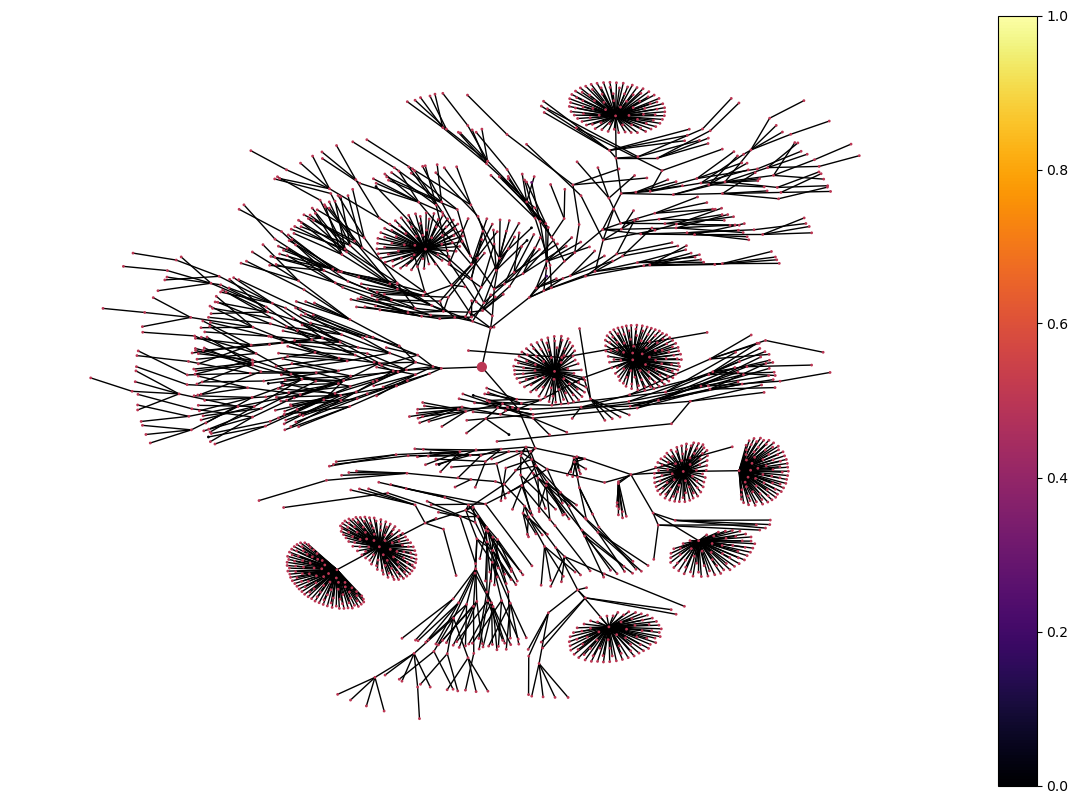

In [28]:
from evomol.plot_exploration import exploration_graph
exploration_graph(
    model_path="evo_gen/exp/", layout="neato")